# E-Commerce Sales Analysis and Machine Learning Prediction

This is the **whole project in one notebook**.

It does everything in order:
1. Load the data.
2. Check data quality.
3. Clean the data.
4. Explore and make charts.
5. Build new features.
6. Split into train / test (no data leakage).
7. Train 5 models.
8. Compare them with MAE, MSE, RMSE and R².
9. Tune the strong tree models.
10. Save the best model and a report.

**Run the cells from top to bottom.**

All comments and explanations use simple English.

## Step 0: Settings and imports

In [1]:
# ---------------------------------------------------------
# 0a. Try to install optional packages (so the notebook does not
# stop if one is missing). If a package cannot be installed, we
# print a short message and CONTINUE. The notebook never crashes
# because of this. Required packages (pandas, numpy, matplotlib,
# seaborn, scikit-learn, joblib) are usually already installed.
# ---------------------------------------------------------
import importlib
import subprocess
import sys

OPTIONAL = ["plotly", "xgboost"]
AVAILABLE = {}          # pkg name -> True / False

for pkg in OPTIONAL:
    try:
        importlib.import_module(pkg)
        AVAILABLE[pkg] = True
        print(f"OK: {pkg} is installed.")
    except ImportError:
        print(f"Missing: {pkg}. Trying to install it...")
        try:
            subprocess.check_call([sys.executable, "-m", "pip", "install",
                                   "-q", pkg], env=None, stdout=subprocess.DEVNULL)
        except Exception as exc:
            print(f"Could not install {pkg} ({exc}). Skipping it.")
            AVAILABLE[pkg] = False
        else:
            try:
                importlib.import_module(pkg)
                AVAILABLE[pkg] = True
                print(f"Installed: {pkg}.")
            except ImportError:
                AVAILABLE[pkg] = False
                print(f"Still cannot import {pkg}. Skipping it.")

print("\nOptional packages status:")
for pkg in OPTIONAL:
    print(f"  - {pkg}: {'ready' if AVAILABLE.get(pkg) else 'not available'}")

# This flag is used later so the models step picks XGBoost only when
# it is really importable.
XGBOOST_AVAILABLE = AVAILABLE.get("xgboost", False)
PLOTLY_AVAILABLE = AVAILABLE.get("plotly", False)

OK: plotly is installed.
OK: xgboost is installed.

Optional packages status:
  - plotly: ready
  - xgboost: ready


In [2]:
import time
import warnings
from pathlib import Path

import joblib
%matplotlib inline
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from xgboost import XGBRegressor
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import (
    GridSearchCV,
    cross_val_score,
    train_test_split
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="muted")

## Step 1: Settings (paths, colors, names)

In [3]:
PROJECT_ROOT = Path.cwd()
RAW_DATA_PATH = PROJECT_ROOT / "data" / "raw" / "superstore.csv"
PROCESSED_DATA_PATH = PROJECT_ROOT / "data" / "processed" / "cleaned_superstore.csv"

OUTPUT_DIR = PROJECT_ROOT / "outputs"
CHARTS_DIR = OUTPUT_DIR / "charts"
MODELS_DIR = OUTPUT_DIR / "models"
REPORTS_DIR = OUTPUT_DIR / "reports"

RANDOM_STATE = 42
TEST_SIZE = 0.20
PLOT_DPI = 150

COLOR_MAIN = "#4C72B0"
COLOR_SECOND = "#DD8452"

# Different versions of the Superstore file use different column names.
# This map changes many possible raw names into one clean name.
COLUMN_MAP = {
    "row id": "row_id", "row_id": "row_id",
    "order id": "order_id", "order_id": "order_id",
    "order date": "order_date", "order_date": "order_date",
    "ship date": "ship_date", "ship_date": "ship_date",
    "ship mode": "ship_mode", "ship_mode": "ship_mode",
    "customer id": "customer_id", "customer_id": "customer_id",
    "customer name": "customer_name", "customer": "customer_name",
    "customer_name": "customer_name", "segment": "segment",
    "customer segment": "segment", "country": "country",
    "city": "city", "state": "state", "province": "state",
    "postal code": "postal_code", "zip": "postal_code",
    "postal_code": "postal_code", "region": "region",
    "product id": "product_id", "product_id": "product_id",
    "category": "category", "product category": "category",
    "sub-category": "sub_category", "sub category": "sub_category",
    "subcategory": "sub_category", "product sub-category": "sub_category",
    "sub_category": "sub_category",
    "product name": "product_name", "product_name": "product_name",
    "sales": "sales", "quantity": "quantity", "order quantity": "quantity",
    "discount": "discount", "profit": "profit",
    "profit margin": "profit_margin", "profit_margin": "profit_margin",
}

DATE_COLUMNS = ["order_date", "ship_date"]

ML_NUMERIC_FEATURES = ["quantity", "discount", "order_year", "order_month",
                       "order_day", "order_weekday", "shipping_days"]
ML_CATEGORICAL_FEATURES = ["segment", "category", "sub_category", "region"]
TARGET_COLUMN = "sales"

# Columns that must not be used to predict sales (they cause leakage or
# are identifiers).
EXCLUDED_ML_COLUMNS = ["order_id", "customer_name", "customer_id",
                       "product_name", "product_id", "row_id", "city",
                       "state", "country", "postal_code", "order_date",
                       "ship_date", "profit", "profit_margin"]


def ensure_directories():
    """Create the output folders if they do not exist yet."""
    for folder in [RAW_DATA_PATH.parent, PROCESSED_DATA_PATH.parent,
                   CHARTS_DIR, MODELS_DIR, REPORTS_DIR]:
        folder.mkdir(parents=True, exist_ok=True)

## Step 2: Load the data and check its quality

In [4]:
# We put the data in a folder next to the notebook.
PROJECT_ROOT = Path.cwd()
RAW_DIR = PROJECT_ROOT / "data" / "raw"
RAW_DIR.mkdir(parents=True, exist_ok=True)
RAW_DATA_PATH = RAW_DIR / "superstore.csv"

# Source URL for the public Superstore dataset.
DATASET_URL = "https://raw.githubusercontent.com/nileshely/SuperStore-Dataset-2019-2022/main/superstore_dataset.csv"


def download_dataset(url, path):
    """Download the dataset from a URL and save it to a local file."""
    import urllib.request
    print(f"Data file not found. Downloading it from:\n  {url}")
    req = urllib.request.Request(url, headers={"User-Agent": "Mozilla/5.0"})
    data = urllib.request.urlopen(req, timeout=60).read()
    with open(path, "wb") as f:
        f.write(data)
    print(f"Downloaded {len(data)} bytes to {path}")


def load_data(file_path=None, encoding="utf-8"):
    """Read the CSV file into a pandas DataFrame.

    If the local file does not exist, we download the dataset first.
    That makes this notebook self-contained (it works on a fresh
    computer without placing the file by hand).
    """
    if file_path is None:
        file_path = RAW_DATA_PATH
    path = Path(file_path)

    if not path.exists():
        download_dataset(DATASET_URL, path)

    for enc in [encoding, "latin-1"]:
        try:
            return pd.read_csv(path, encoding=enc)
        except UnicodeDecodeError:
            continue
    raise ValueError(f"Could not read the file: {path}")


def get_dataset_summary(df):
    """Print a small summary of the data."""
    print("First 5 rows:")
    print(df.head())
    print(f"\nRows: {df.shape[0]}  Columns: {df.shape[1]}")
    print("Column names:", list(df.columns))
    print("\nData types:\n", df.dtypes)
    print("\nBasic statistics:\n", df.describe())


def get_data_quality_table(df):
    """Build a table with column type, missing count and missing percent."""
    rows = []
    for col in df.columns:
        missing = df[col].isna().sum()
        rows.append({"Column": col, "Data Type": str(df[col].dtype),
                     "Missing Values": missing,
                     "Missing Percentage": round(missing / len(df) * 100, 2),
                     "Unique Values": df[col].nunique()})
    return pd.DataFrame(rows)


df = load_data()
get_dataset_summary(df)

First 5 rows:
         order_id order_date  ship_date       customer   manufactory  \
0  US-2020-103800   1/3/2019   1/7/2019  Darren Powers  Message Book   
1  US-2020-112326   1/4/2019   1/8/2019  Phillina Ober           GBC   
2  US-2020-112326   1/4/2019   1/8/2019  Phillina Ober         Avery   
3  US-2020-112326   1/4/2019   1/8/2019  Phillina Ober         SAFCO   
4  US-2020-141817   1/5/2019  1/12/2019     Mick Brown         Avery   

                                        product_name      segment  \
0  Message Book, Wirebound, Four 5 1/2" X 4" Form...     Consumer   
1         GBC Standard Plastic Binding Systems Combs  Home Office   
2                                          Avery 508  Home Office   
3                      SAFCO Boltless Steel Shelving  Home Office   
4  Avery Hi-Liter EverBold Pen Style Fluorescent ...     Consumer   

          category subcategory   region    zip          city         state  \
0  Office Supplies       Paper  Central  77095       Houston

**Data quality table:**

In [5]:
quality = get_data_quality_table(df)
quality

,Column,Data Type,Missing Values,Missing Percentage,Unique Values
0,order_id,object,0,0.0,5009
1,order_date,object,0,0.0,1236
2,ship_date,object,0,0.0,1334
3,customer,object,0,0.0,793
4,manufactory,object,0,0.0,182
5,product_name,object,0,0.0,1849
6,segment,object,0,0.0,3
7,category,object,0,0.0,3
8,subcategory,object,0,0.0,17
9,region,object,0,0.0,4


## Step 3: Clean the data

In [6]:
def clean_column_names(df):
    """Make column names lowercase with underscores."""
    df = df.copy()
    df.columns = [str(c).strip().lower().replace(" ", "_") for c in df.columns]
    return df


def map_column_names(df):
    """Change many possible raw names into one clean name."""
    df = df.copy()
    rename = {c: COLUMN_MAP[c] for c in df.columns if c in COLUMN_MAP}
    return df.rename(columns=rename)


def handle_missing_values(df):
    """Fill or remove missing values in a safe way."""
    df = df.copy()
    important = [c for c in DATE_COLUMNS if c in df.columns]
    if TARGET_COLUMN in df.columns:
        important.append(TARGET_COLUMN)
    if important:
        df = df.dropna(subset=important).reset_index(drop=True)
    for col in df.select_dtypes(include=["object"]).columns:
        df[col] = df[col].replace(r"^\s*$", np.nan, regex=True)
    for col in df.select_dtypes(include=["object"]).columns:
        if df[col].isna().sum() > 0:
            df[col] = df[col].fillna(df[col].mode().iloc[0] if not df[col].mode().empty else "unknown")
    for col in df.select_dtypes(include=[np.number]).columns:
        if df[col].isna().sum() > 0:
            df[col] = df[col].fillna(df[col].median())
    return df


def remove_duplicates(df):
    """Remove rows that are completely the same."""
    df = df.copy()
    subset = [c for c in ["order_id", "product_name", "customer_name", "order_date"]
              if c in df.columns]
    before = len(df)
    df = df.drop_duplicates(subset=subset if subset else None).reset_index(drop=True)
    if before - len(df):
        print(f"Removed {before - len(df)} duplicate rows.")
    return df


def convert_dates(df):
    """Turn the date columns into real datetime values."""
    df = df.copy()
    for col in DATE_COLUMNS:
        if col in df.columns:
            df[col] = pd.to_datetime(df[col], errors="coerce")
    return df


def fix_numeric_columns(df):
    """Make numbers clean and reasonable."""
    df = df.copy()
    for col in ["sales", "profit", "quantity", "discount"]:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce")
    if "sales" in df.columns:
        df.loc[df["sales"] < 0, "sales"] = 0
    if "discount" in df.columns:
        df["discount"] = df["discount"].clip(0, 1)
    if "quantity" in df.columns:
        df["quantity"] = df["quantity"].round().clip(lower=0).astype(float)
    return df


def clean_dataset(df):
    """Run the whole cleaning process on a copy of the data."""
    print("Starting data cleaning...")
    df = df.copy()
    df = clean_column_names(df)
    df = map_column_names(df)
    df = df.dropna(axis=1, how="all")
    df = df.dropna(how="all").reset_index(drop=True)
    df = handle_missing_values(df)
    df = remove_duplicates(df)
    df = convert_dates(df)
    df = fix_numeric_columns(df)
    print(f"Finished cleaning. Now {df.shape[0]} rows and {df.shape[1]} columns.")
    return df


def save_cleaned_data(df):
    """Save the cleaned data to a CSV file."""
    ensure_directories()
    df.to_csv(PROCESSED_DATA_PATH, index=False)
    print(f"Saved cleaned data to: {PROCESSED_DATA_PATH}")


cleaned = clean_dataset(df)
save_cleaned_data(cleaned)

Starting data cleaning...
Removed 8 duplicate rows.
Finished cleaning. Now 9986 rows and 19 columns.
Saved cleaned data to: c:\Users\modernkade\Desktop\pythom\Github\SuperStore\data\processed\cleaned_superstore.csv


## Step 4: Exploratory summary

In [7]:
print(f"Total sales     : ${cleaned['sales'].sum():,.0f}")
print(f"Average sales   : ${cleaned['sales'].mean():,.2f}")
print(f"Median sales    : ${cleaned['sales'].median():,.2f}")
print(f"Total profit    : ${cleaned['profit'].sum():,.0f}")
print(f"Unique customers: {cleaned['customer_name'].nunique()}")
print(f"Orders with loss: {(cleaned['profit'] < 0).sum()}")
print(f"Date range      : {cleaned['order_date'].min()} to {cleaned['order_date'].max()}")
print("\nSales by category:")
print(cleaned.groupby("category")["sales"].sum().sort_values(ascending=False))
print("\nProfit by category:")
print(cleaned.groupby("category")["profit"].sum().sort_values(ascending=False))
print("\nSales by region:")
print(cleaned.groupby("region")["sales"].sum().sort_values(ascending=False))

Total sales     : $2,295,510
Average sales   : $229.87
Median sales    : $54.38
Total profit    : $286,014
Unique customers: 793
Orders with loss: 1870
Date range      : 2019-01-03 00:00:00 to 2022-12-30 00:00:00

Sales by category:
category
Technology         835759.7370
Furniture          741432.0433
Office Supplies    718317.7920
Name: sales, dtype: float64

Profit by category:
category
Technology         145386.1344
Office Supplies    122247.4038
Furniture           18380.2814
Name: profit, dtype: float64

Sales by region:
region
West       725355.4885
East       677906.3680
Central    501239.8908
South      391007.8250
Name: sales, dtype: float64


## Step 5: Chart functions

In [8]:
def _save(fig, filename):
    """Save a figure into the charts folder."""
    ensure_directories()
    path = CHARTS_DIR / filename
    fig.savefig(path, dpi=PLOT_DPI)
    plt.show()   # Show the chart here, inside the notebook.
    plt.close(fig)
    print(f"Chart saved: {path}")
    return path


def _bar(df, ax, x, y, title, color=None, xlabel=None, ylabel=None):
    color = color or COLOR_MAIN
    ax.bar(df[x].astype(str), df[y], color=color, edgecolor="white", linewidth=0.5)
    ax.set_title(title)
    ax.set_xlabel(xlabel or x)
    ax.set_ylabel(ylabel or y)


def plot_sales_by_category(df):
    d = df.groupby("category")["sales"].sum().sort_values(ascending=False)
    fig, ax = plt.subplots(figsize=(8, 5))
    _bar(d.reset_index(), ax, "category", "sales", "Total Sales by Category",
         xlabel="Category", ylabel="Total Sales")
    for i, v in enumerate(d.values):
        ax.text(i, v, f"{v:,.0f}", ha="center", va="bottom", fontsize=9)
    _save(fig, "sales_by_category.png")


def plot_profit_by_category(df):
    d = df.groupby("category")["profit"].sum().sort_values(ascending=False)
    colors = [COLOR_MAIN if v >= 0 else COLOR_SECOND for v in d.values]
    fig, ax = plt.subplots(figsize=(8, 5))
    _bar(d.reset_index(), ax, "category", "profit", "Total Profit by Category",
         color=colors, xlabel="Category", ylabel="Total Profit")
    for i, v in enumerate(d.values):
        ax.text(i, v, f"{v:,.0f}", ha="center", va="bottom", fontsize=9)
    _save(fig, "profit_by_category.png")


def plot_sales_by_region(df):
    d = df.groupby("region")["sales"].sum().sort_values(ascending=False)
    fig, ax = plt.subplots(figsize=(8, 5))
    _bar(d.reset_index(), ax, "region", "sales", "Total Sales by Region",
         color=COLOR_SECOND, xlabel="Region", ylabel="Total Sales")
    for i, v in enumerate(d.values):
        ax.text(i, v, f"{v:,.0f}", ha="center", va="bottom", fontsize=9)
    _save(fig, "sales_by_region.png")


def plot_profit_by_region(df):
    d = df.groupby("region")["profit"].sum().sort_values(ascending=False)
    colors = [COLOR_MAIN if v >= 0 else COLOR_SECOND for v in d.values]
    fig, ax = plt.subplots(figsize=(8, 5))
    _bar(d.reset_index(), ax, "region", "profit", "Total Profit by Region",
         color=colors, xlabel="Region", ylabel="Total Profit")
    for i, v in enumerate(d.values):
        ax.text(i, v, f"{v:,.0f}", ha="center", va="bottom", fontsize=9)
    _save(fig, "profit_by_region.png")


def plot_monthly_sales(df):
    m = df.set_index("order_date").resample("MS")["sales"].sum()
    fig, ax = plt.subplots(figsize=(12, 5))
    ax.plot(m.index, m.values, color=COLOR_MAIN, marker="o", markersize=4, linewidth=2)
    ax.set_title("Monthly Sales Trend")
    ax.set_xlabel("Month"); ax.set_ylabel("Total Sales")
    ax.tick_params(axis="x", rotation=45)
    _save(fig, "monthly_sales_trend.png")


def plot_monthly_profit(df):
    m = df.set_index("order_date").resample("MS")["profit"].sum()
    fig, ax = plt.subplots(figsize=(12, 5))
    ax.plot(m.index, m.values, color=COLOR_SECOND, marker="o", markersize=4, linewidth=2)
    ax.axhline(0, color="red", linestyle="--", linewidth=1)
    ax.set_title("Monthly Profit Trend")
    ax.set_xlabel("Month"); ax.set_ylabel("Total Profit")
    ax.tick_params(axis="x", rotation=45)
    _save(fig, "monthly_profit_trend.png")


def plot_top_products(df, n=10):
    d = df.groupby("product_name")["sales"].sum().sort_values(ascending=False).head(n)
    fig, ax = plt.subplots(figsize=(10, 7))
    ax.barh(d.index.astype(str)[::-1], d.values[::-1], color=COLOR_MAIN, edgecolor="white")
    ax.set_title(f"Top {n} Products by Sales")
    ax.set_xlabel("Total Sales"); ax.set_ylabel("Product")
    ax.tick_params(axis="y", labelsize=8)
    _save(fig, "top_products_by_sales.png")


def plot_top_customers(df, n=10):
    d = df.groupby("customer_name")["sales"].sum().sort_values(ascending=False).head(n)
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.barh(d.index.astype(str)[::-1], d.values[::-1], color=COLOR_SECOND, edgecolor="white")
    ax.set_title(f"Top {n} Customers by Sales")
    ax.set_xlabel("Total Sales"); ax.set_ylabel("Customer")
    ax.tick_params(axis="y", labelsize=8)
    _save(fig, "top_customers_by_sales.png")


def plot_discount_vs_profit(df):
    d = df.groupby("discount")["profit"].mean().reset_index()
    fig, ax = plt.subplots(figsize=(9, 5))
    ax.scatter(d["discount"], d["profit"], color=COLOR_SECOND, s=60, alpha=0.8)
    ax.axhline(0, color="red", linestyle="--", linewidth=1)
    ax.set_title("Average Profit by Discount Level")
    ax.set_xlabel("Discount (0 to 1)"); ax.set_ylabel("Average Profit")
    _save(fig, "discount_vs_profit.png")


def plot_sales_vs_profit(df):
    fig, ax = plt.subplots(figsize=(9, 5))
    ax.scatter(df["sales"], df["profit"], color=COLOR_MAIN, alpha=0.25, s=12)
    ax.axhline(0, color="red", linestyle="--", linewidth=1)
    ax.set_title("Sales vs Profit")
    ax.set_xlabel("Sales"); ax.set_ylabel("Profit")
    _save(fig, "sales_vs_profit.png")


def plot_sales_distribution(df):
    fig, ax = plt.subplots(figsize=(9, 5))
    sns.histplot(df["sales"], bins=50, kde=True, color=COLOR_MAIN, ax=ax)
    ax.set_title("Sales Distribution")
    ax.set_xlabel("Sales"); ax.set_ylabel("Number of Orders")
    _save(fig, "sales_distribution.png")


def plot_correlation_heatmap(df):
    numeric = df.select_dtypes(include=[np.number]).drop(
        columns=[c for c in ["postal_code", "row_id"] if c in df.columns], errors="ignore")
    corr = numeric.corr()
    fig, ax = plt.subplots(figsize=(9, 7))
    sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5,
                ax=ax, cbar_kws={"shrink": 0.8})
    ax.set_title("Correlation Heatmap for Numeric Features")
    _save(fig, "correlation_heatmap.png")


def plot_profit_by_subcategory(df):
    d = df.groupby("sub_category")["profit"].sum().sort_values(ascending=False)
    colors = [COLOR_MAIN if v >= 0 else COLOR_SECOND for v in d.values]
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.bar(d.index.astype(str), d.values, color=colors, edgecolor="white")
    ax.set_title("Total Profit by Sub Category")
    ax.set_xlabel("Sub Category"); ax.set_ylabel("Total Profit")
    ax.tick_params(axis="x", rotation=45)
    _save(fig, "profit_by_subcategory.png")


def plot_negative_profit_products(df, n=10):
    d = df.groupby("product_name")["profit"].sum().sort_values().head(n)
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.barh(d.index.astype(str)[::-1], d.values[::-1], color=COLOR_SECOND, edgecolor="white")
    ax.set_title(f"Top {n} Products with the Biggest Losses")
    ax.set_xlabel("Total Profit (negative = loss)"); ax.set_ylabel("Product")
    ax.tick_params(axis="y", labelsize=8)
    _save(fig, "negative_profit_products.png")


def plot_yearly_sales(df):
    work = df.copy()
    if "order_year" not in work.columns and "order_date" in work.columns:
        work["order_year"] = pd.to_datetime(work["order_date"]).dt.year
    d = work.groupby("order_year")["sales"].sum()
    fig, ax = plt.subplots(figsize=(8, 5))
    _bar(d.reset_index(), ax, "order_year", "sales", "Total Sales by Year",
         xlabel="Year", ylabel="Total Sales")
    for i, v in enumerate(d.values):
        ax.text(i, v, f"{v:,.0f}", ha="center", va="bottom", fontsize=9)
    _save(fig, "yearly_sales.png")

### Make the main charts

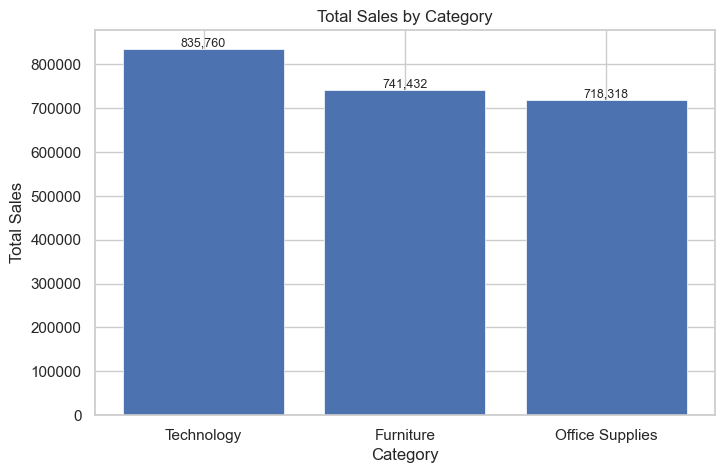

Chart saved: c:\Users\modernkade\Desktop\pythom\Github\SuperStore\outputs\charts\sales_by_category.png


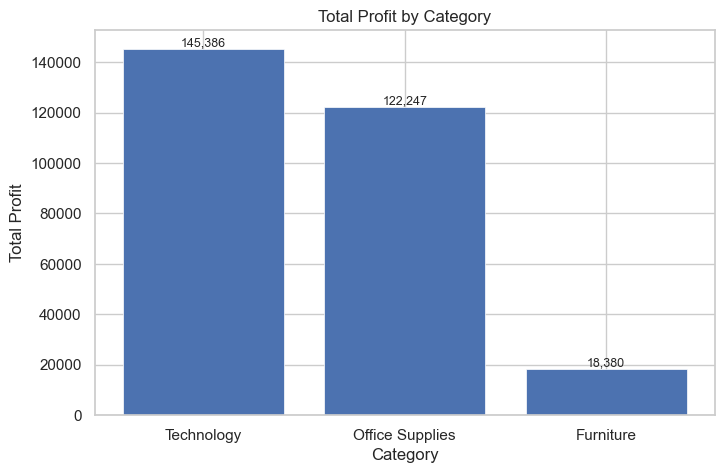

Chart saved: c:\Users\modernkade\Desktop\pythom\Github\SuperStore\outputs\charts\profit_by_category.png


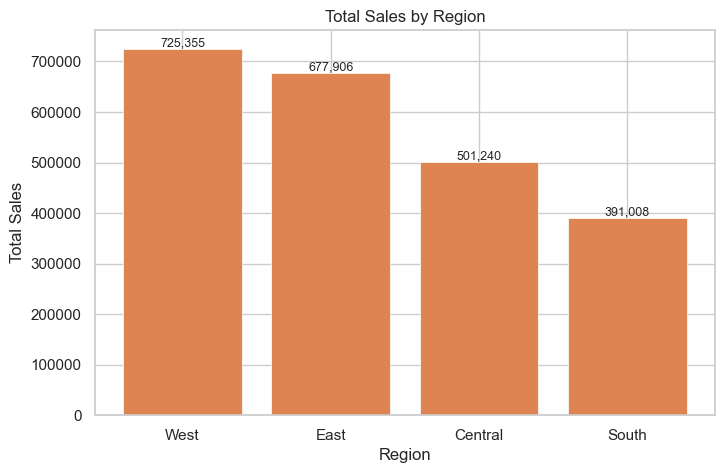

Chart saved: c:\Users\modernkade\Desktop\pythom\Github\SuperStore\outputs\charts\sales_by_region.png


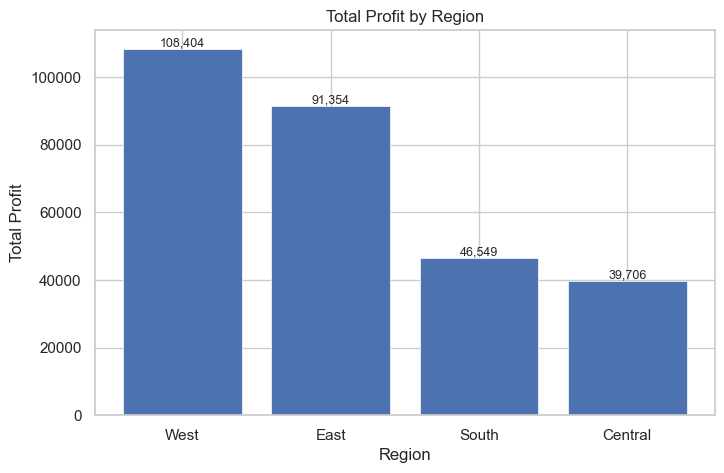

Chart saved: c:\Users\modernkade\Desktop\pythom\Github\SuperStore\outputs\charts\profit_by_region.png


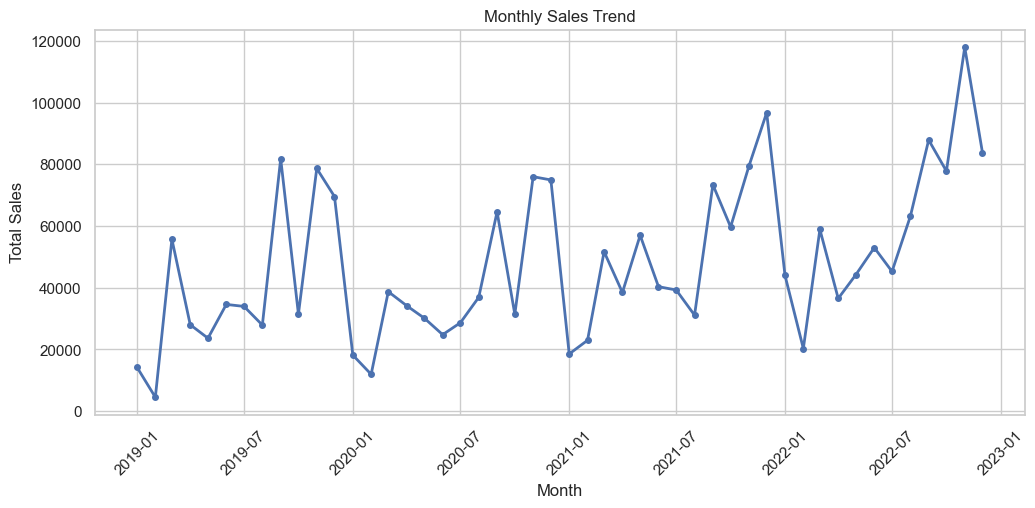

Chart saved: c:\Users\modernkade\Desktop\pythom\Github\SuperStore\outputs\charts\monthly_sales_trend.png


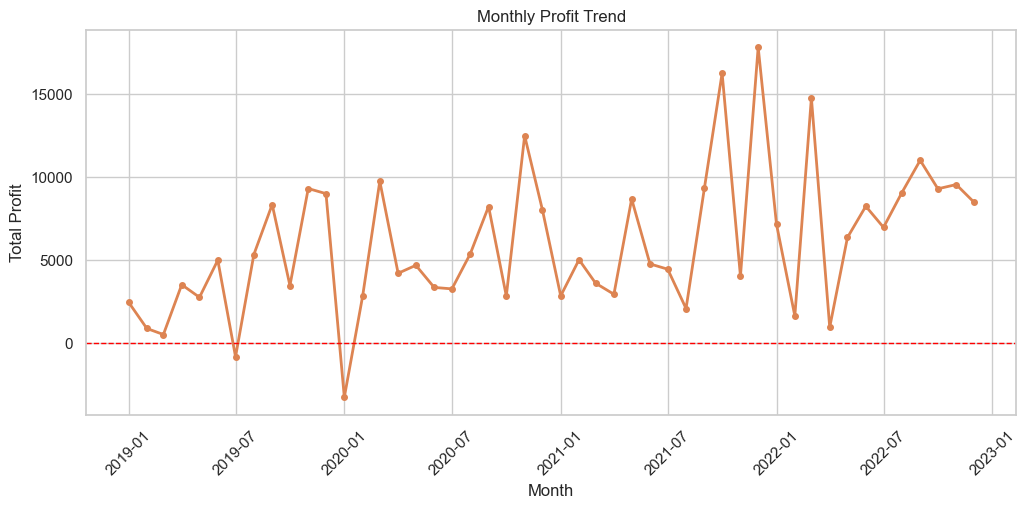

Chart saved: c:\Users\modernkade\Desktop\pythom\Github\SuperStore\outputs\charts\monthly_profit_trend.png


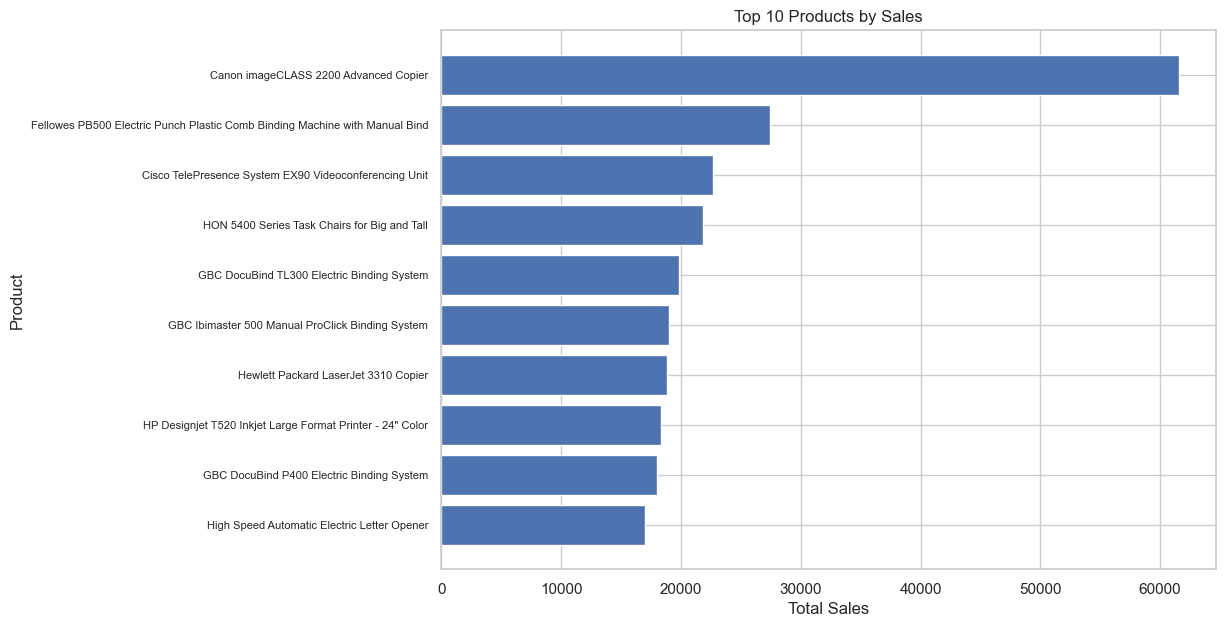

Chart saved: c:\Users\modernkade\Desktop\pythom\Github\SuperStore\outputs\charts\top_products_by_sales.png


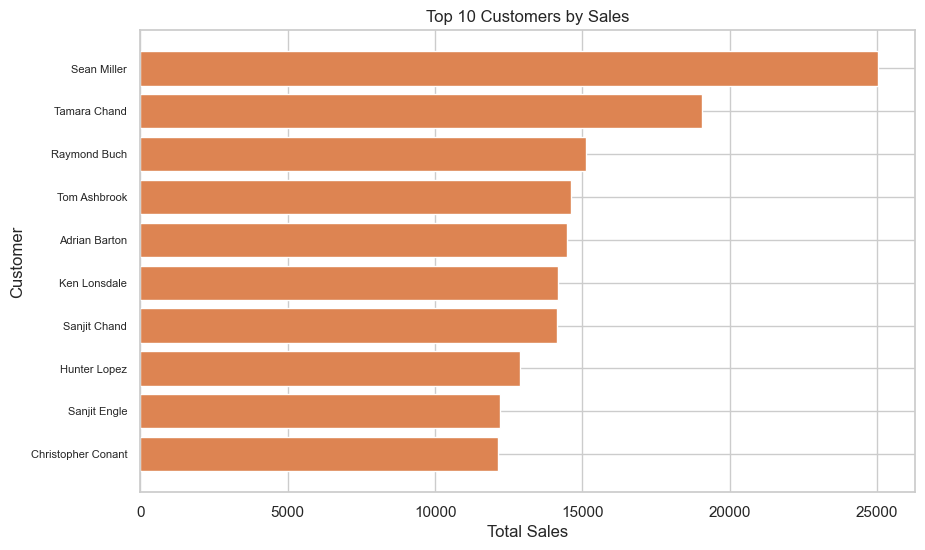

Chart saved: c:\Users\modernkade\Desktop\pythom\Github\SuperStore\outputs\charts\top_customers_by_sales.png


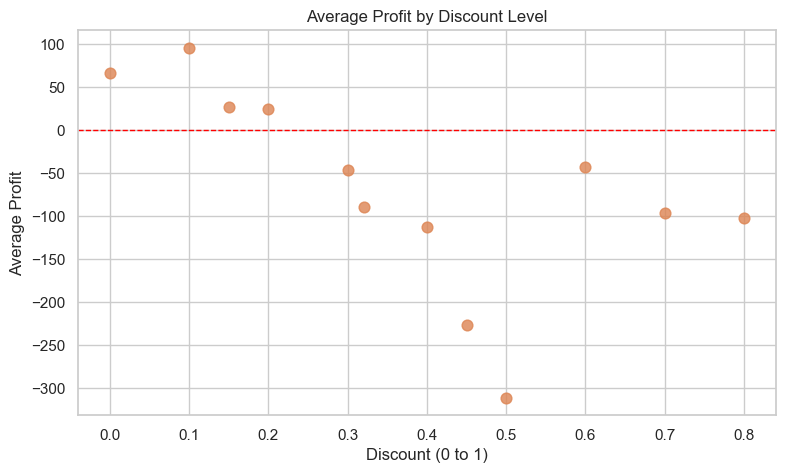

Chart saved: c:\Users\modernkade\Desktop\pythom\Github\SuperStore\outputs\charts\discount_vs_profit.png


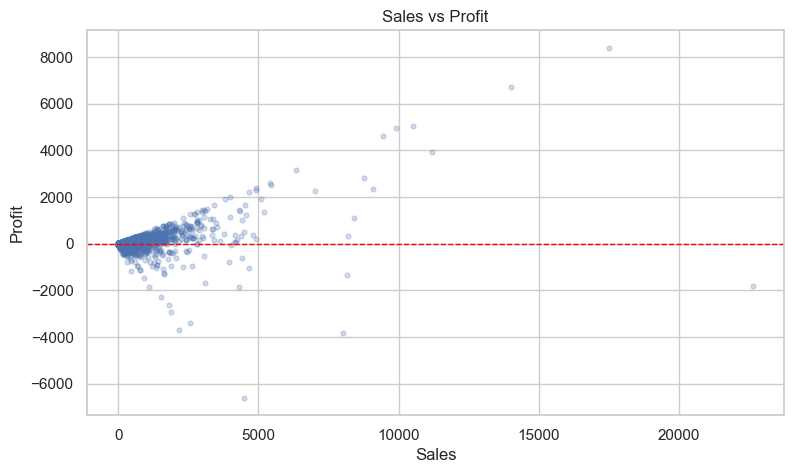

Chart saved: c:\Users\modernkade\Desktop\pythom\Github\SuperStore\outputs\charts\sales_vs_profit.png


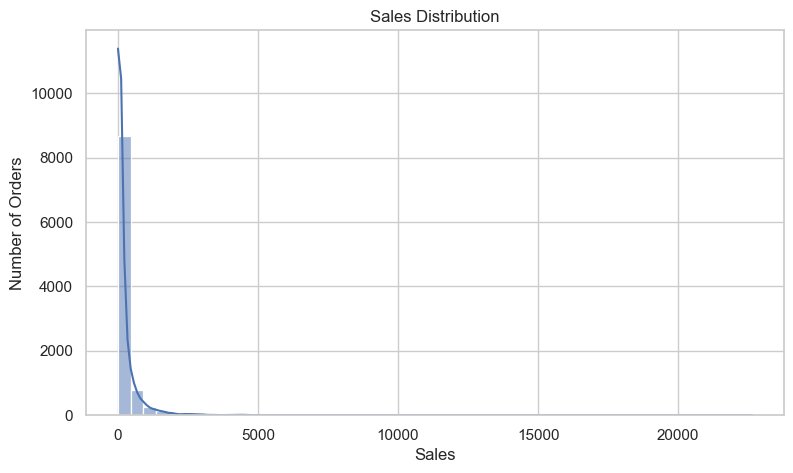

Chart saved: c:\Users\modernkade\Desktop\pythom\Github\SuperStore\outputs\charts\sales_distribution.png


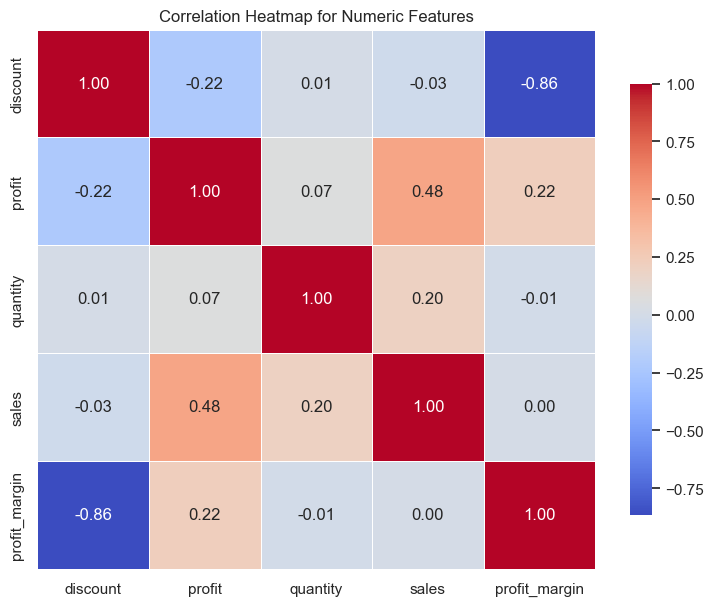

Chart saved: c:\Users\modernkade\Desktop\pythom\Github\SuperStore\outputs\charts\correlation_heatmap.png


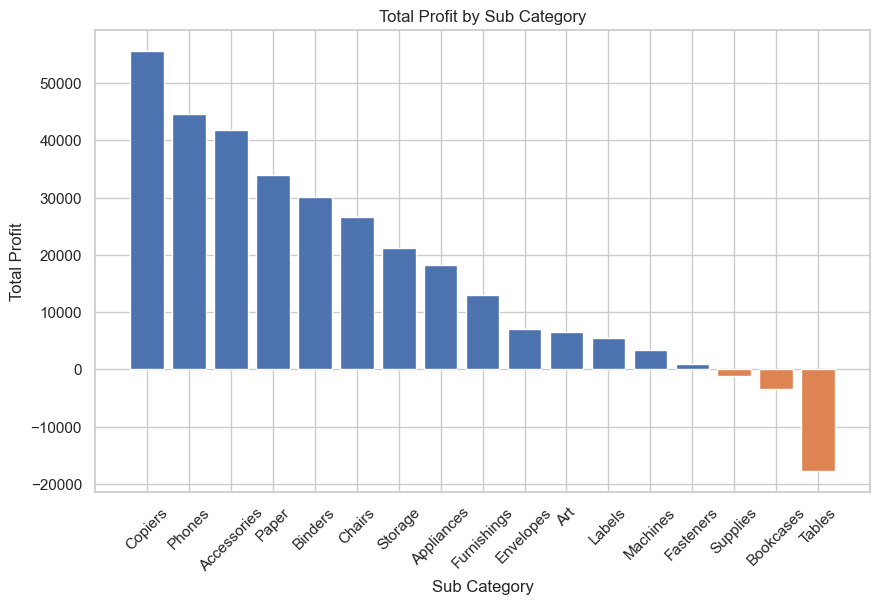

Chart saved: c:\Users\modernkade\Desktop\pythom\Github\SuperStore\outputs\charts\profit_by_subcategory.png


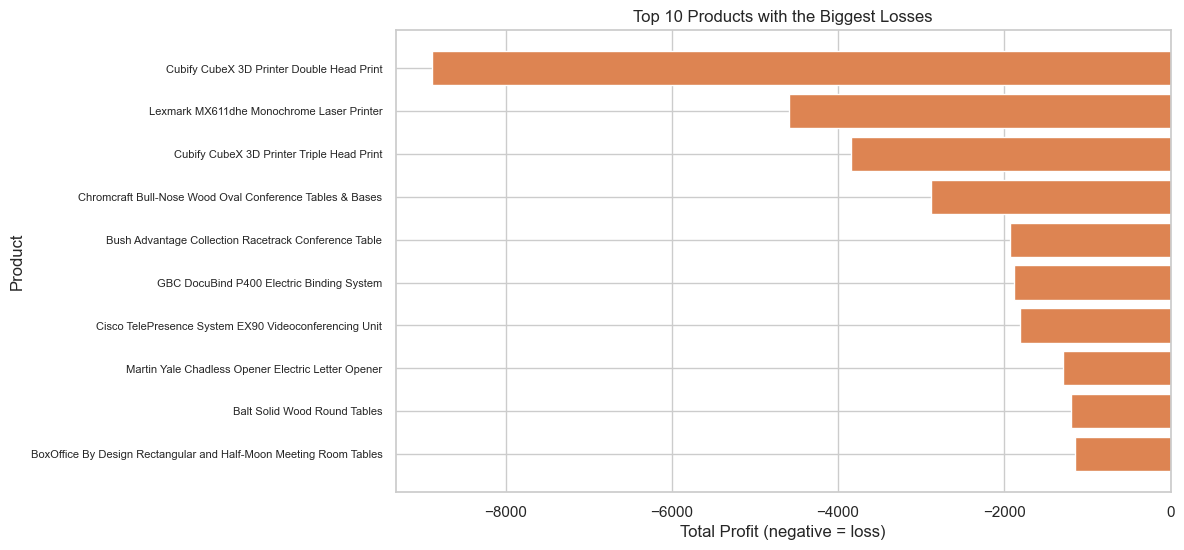

Chart saved: c:\Users\modernkade\Desktop\pythom\Github\SuperStore\outputs\charts\negative_profit_products.png


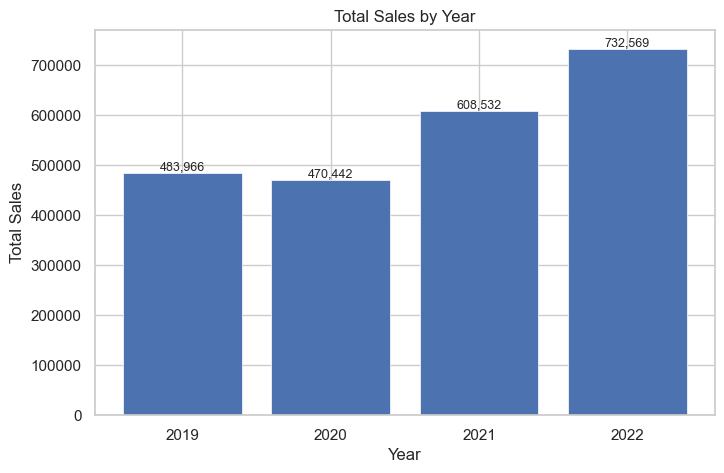

Chart saved: c:\Users\modernkade\Desktop\pythom\Github\SuperStore\outputs\charts\yearly_sales.png


In [9]:
plot_sales_by_category(cleaned)
plot_profit_by_category(cleaned)
plot_sales_by_region(cleaned)
plot_profit_by_region(cleaned)
plot_monthly_sales(cleaned)
plot_monthly_profit(cleaned)
plot_top_products(cleaned)
plot_top_customers(cleaned)
plot_discount_vs_profit(cleaned)
plot_sales_vs_profit(cleaned)
plot_sales_distribution(cleaned)
plot_correlation_heatmap(cleaned)
plot_profit_by_subcategory(cleaned)
plot_negative_profit_products(cleaned)
plot_yearly_sales(cleaned)

### Interactive Plotly charts (saved as small HTML files)

In [10]:
# ---------------------------------------------------------
# Interactive Plotly charts.
# These are a "nice to have" extra. Plotly is an optional library.
# If it is not installed, we print a short message and carry on,
# because the main PNG charts (matplotlib) are already saved.
# ---------------------------------------------------------
def plotly_available():
    """Return True if the plotly library is installed."""
    try:
        import plotly.graph_objects  # noqa: F401
        return True
    except ImportError:
        return False


def interactive_dashboard(df):
    """Create a small interactive dashboard saved as one HTML page."""
    from plotly.subplots import make_subplots
    import plotly.graph_objects as go
    ensure_directories()
    path = CHARTS_DIR / "interactive_dashboard.html"
    sub_cat = df.groupby("sub_category")["sales"].sum().sort_values(ascending=True).tail(15)
    sales_cat = df.groupby("category")["sales"].sum().reset_index()
    profit_reg = df.groupby("region")["profit"].sum().reset_index()
    monthly = df.set_index("order_date").resample("MS")["sales"].sum().reset_index()

    fig = make_subplots(rows=2, cols=2, subplot_titles=(
        "Sales by Category", "Profit by Region",
        "Top Sub Categories by Sales", "Monthly Sales Trend"))
    fig.add_bar(x=sales_cat["category"], y=sales_cat["sales"],
                marker_color=COLOR_MAIN, row=1, col=1)
    fig.add_bar(x=profit_reg["region"], y=profit_reg["profit"],
                marker_color=COLOR_SECOND, row=1, col=2)
    fig.add_bar(y=sub_cat.index, x=sub_cat.values, orientation="h",
                marker_color="#55A868", row=2, col=1)
    fig.add_scatter(x=monthly["order_date"], y=monthly["sales"],
                    mode="lines+markers", line=dict(color=COLOR_SECOND),
                    row=2, col=2)
    fig.update_layout(title="Superstore Interactive Sales Dashboard",
                      height=700, showlegend=False, template="plotly_white")
    fig.write_html(path, include_plotlyjs="cdn")
    print(f"Chart saved: {path}")
    return path


def interactive_monthly_sales(df):
    """Create an interactive monthly sales chart saved as HTML."""
    import plotly.graph_objects as go
    ensure_directories()
    path = CHARTS_DIR / "interactive_monthly_sales.html"
    monthly = df.set_index("order_date").resample("MS")["sales"].sum().reset_index()
    fig = go.Figure(go.Scatter(x=monthly["order_date"], y=monthly["sales"],
                               mode="lines+markers", name="Monthly Sales",
                               fill="tozeroy", line=dict(color=COLOR_MAIN)))
    fig.update_layout(title="Interactive Monthly Sales",
                      xaxis_title="Month", yaxis_title="Sales")
    fig.write_html(path, include_plotlyjs="cdn")
    print(f"Chart saved: {path}")
    return path


if plotly_available():
    interactive_monthly_sales(cleaned)
    interactive_dashboard(cleaned)
else:
    print("Plotly is not installed, so the interactive HTML charts are skipped.")
    print("The main PNG charts were already saved. To install Plotly run:")
    print("    pip install plotly")

# ---------------------------------------------------------
# Optional package check for the models.
# XGBoost is handled inside get_models() with a safe fallback.
# ---------------------------------------------------------


Chart saved: c:\Users\modernkade\Desktop\pythom\Github\SuperStore\outputs\charts\interactive_monthly_sales.html
Chart saved: c:\Users\modernkade\Desktop\pythom\Github\SuperStore\outputs\charts\interactive_dashboard.html


## Step 6: Feature engineering

In [11]:
def build_features(df):
    """Add the features used for analysis and for machine learning."""
    df = df.copy()
    if "order_date" in df.columns:
        date = pd.to_datetime(df["order_date"], errors="coerce")
        df["order_year"] = date.dt.year
        df["order_month"] = date.dt.month
        df["order_day"] = date.dt.day
        df["order_weekday"] = date.dt.weekday
    if "order_date" in df.columns and "ship_date" in df.columns:
        order = pd.to_datetime(df["order_date"], errors="coerce")
        ship = pd.to_datetime(df["ship_date"], errors="coerce")
        df["shipping_days"] = (ship - order).dt.days
        df["shipping_days"] = df["shipping_days"].fillna(df["shipping_days"].median())
        df["shipping_days"] = df["shipping_days"].clip(lower=0, upper=30)
    safe_sales = df["sales"].replace(0, np.nan)
    df["profit_margin"] = (df["profit"] / safe_sales).fillna(0)
    return df


featured = build_features(cleaned)
featured[["order_year", "order_month", "order_day", "order_weekday",
          "shipping_days"]].head()

,order_year,order_month,order_day,order_weekday,shipping_days
0,2019,1,3,3,4
1,2019,1,4,4,4
2,2019,1,4,4,4
3,2019,1,4,4,4
4,2019,1,5,5,7


In [12]:
def available_features(X):
    """Return the ML features that actually exist in the data."""

    cols = list(X.columns)

    numeric_features = [
        c for c in ML_NUMERIC_FEATURES
        if c in cols
    ]

    categorical_features = [
        c for c in ML_CATEGORICAL_FEATURES
        if c in cols
    ]

    return numeric_features, categorical_features


def create_preprocessor(X=None):
    """
    Build the preprocessing pipeline.

    Numeric features are scaled.
    Categorical features are one-hot encoded.
    """

    if X is None:
        numeric_features = ML_NUMERIC_FEATURES
        categorical_features = ML_CATEGORICAL_FEATURES
    else:
        (
            numeric_features,
            categorical_features
        ) = available_features(X)

    transformers = []

    # Process numeric features
    if numeric_features:

        numeric_pipeline = Pipeline(
            steps=[
                ("scaler", StandardScaler())
            ]
        )

        transformers.append(
            (
                "num",
                numeric_pipeline,
                numeric_features
            )
        )

    # Process categorical features
    if categorical_features:

        categorical_pipeline = Pipeline(
            steps=[
                (
                    "onehot",
                    OneHotEncoder(
                        handle_unknown="ignore"
                    )
                )
            ]
        )

        transformers.append(
            (
                "cat",
                categorical_pipeline,
                categorical_features
            )
        )

    return ColumnTransformer(
        transformers=transformers
    )

## Step 7: Machine learning - preprocessing and models

In [13]:
def get_models():
    """Return all machine learning models used in this project."""

    return {
        "Linear Regression": LinearRegression(),

        "Ridge Regression": Ridge(
            alpha=1.0
        ),

        "Random Forest": RandomForestRegressor(
            n_estimators=200,
            random_state=RANDOM_STATE,
            n_jobs=-1
        ),

        "Gradient Boosting": GradientBoostingRegressor(
            n_estimators=200,
            random_state=RANDOM_STATE
        ),

        "XGBoost": XGBRegressor(
            n_estimators=200,
            learning_rate=0.05,
            max_depth=3,
            random_state=RANDOM_STATE,
            n_jobs=-1,
            objective="reg:squarederror",
            eval_metric="rmse"
        )
    }


def build_and_fit_pipeline(model, X_train, y_train):
    """Combine preprocessing with the model and train it."""

    pipeline = Pipeline(
        steps=[
            ("preprocessor", create_preprocessor(X_train)),
            ("model", model)
        ]
    )

    pipeline.fit(X_train, y_train)

    return pipeline

## Step 8: Prepare the data (no data leakage)

In [14]:
# Drop columns that are identifiers or that come from the target
# (profit and profit margin). Using them would cause data leakage.
data_ml = featured.drop(columns=[c for c in EXCLUDED_ML_COLUMNS
                                 if c in featured.columns], errors="ignore")
X = data_ml[ML_NUMERIC_FEATURES + ML_CATEGORICAL_FEATURES]
y = featured[TARGET_COLUMN]
print("Features:", list(X.columns))
print("Target:", TARGET_COLUMN)

Features: ['quantity', 'discount', 'order_year', 'order_month', 'order_day', 'order_weekday', 'shipping_days', 'segment', 'category', 'sub_category', 'region']
Target: sales


### Train / test split

We use a random split with `random_state=42`. This is fair and easy to repeat. Because the data has a time order, a time-based split can also be useful. For predicting one order's sales from its own features, a random split is fine. A time split is a good extra check.

In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE)
print(f"Train rows: {X_train.shape[0]}  Test rows: {X_test.shape[0]}")

Train rows: 7988  Test rows: 1998


## Step 9: Train, evaluate and compare the models

In [16]:
def evaluate_pipeline(pipeline, X_test, y_test, train_time=None):
    """Evaluate a trained model on the test data."""

    y_pred = pipeline.predict(X_test)

    mae = float(mean_absolute_error(y_test, y_pred))
    mse = float(mean_squared_error(y_test, y_pred))
    rmse = float(np.sqrt(mse))
    r2 = float(r2_score(y_test, y_pred))

    result = {
        "MAE": round(mae, 3),
        "MSE": round(mse, 3),
        "RMSE": round(rmse, 3),
        "R2 Score": round(r2, 4)
    }

    if train_time is not None:
        result["Training Time (s)"] = train_time

    return result


def train_and_evaluate_all(X_train, y_train, X_test, y_test):
    """Train all models and evaluate them on the test data."""

    results = {}

    for name, estimator in get_models().items():

        start = time.time()

        pipeline = build_and_fit_pipeline(
            estimator,
            X_train,
            y_train
        )

        train_time = round(time.time() - start, 3)

        metrics = evaluate_pipeline(
            pipeline,
            X_test,
            y_test,
            train_time
        )

        results[name] = {
            "metrics": metrics,
            "pipeline": pipeline
        }

        print(
            f"Model done: {name:<20} "
            f"MAE = {metrics['MAE']:.3f} "
            f"RMSE = {metrics['RMSE']:.3f} "
            f"R2 = {metrics['R2 Score']:.4f}"
        )

    return results


results = train_and_evaluate_all(
    X_train,
    y_train,
    X_test,
    y_test
)

Model done: Linear Regression    MAE = 197.865 RMSE = 388.883 R2 = 0.3286
Model done: Ridge Regression     MAE = 197.656 RMSE = 388.356 R2 = 0.3304
Model done: Random Forest        MAE = 186.071 RMSE = 411.613 R2 = 0.2478
Model done: Gradient Boosting    MAE = 176.818 RMSE = 399.254 R2 = 0.2923
Model done: XGBoost              MAE = 172.258 RMSE = 381.006 R2 = 0.3555


### Comparison table

In [17]:
def make_comparison_table(results):
    """Build a model comparison table."""

    rows = []

    for name, info in results.items():

        row = {
            "Model": name
        }

        row.update(info["metrics"])

        rows.append(row)

    table = pd.DataFrame(rows)

    # Lower MAE is better.
    # RMSE is used as the second comparison metric.
    # R2 is used as the third metric.
    table = table.sort_values(
        by=["MAE", "RMSE", "R2 Score"],
        ascending=[True, True, False]
    ).reset_index(drop=True)

    return table


table = make_comparison_table(results)

print("=" * 70)
print("MODEL COMPARISON")
print("=" * 70)

display(table)

MODEL COMPARISON


,Model,MAE,MSE,RMSE,R2 Score,Training Time (s)
0,XGBoost,172.258,145165.851,381.006,0.3555,0.732
1,Gradient Boosting,176.818,159404.065,399.254,0.2923,3.118
2,Random Forest,186.071,169425.172,411.613,0.2478,3.416
3,Ridge Regression,197.656,150820.363,388.356,0.3304,0.031
4,Linear Regression,197.865,151230.019,388.883,0.3286,0.056


### Comparison charts

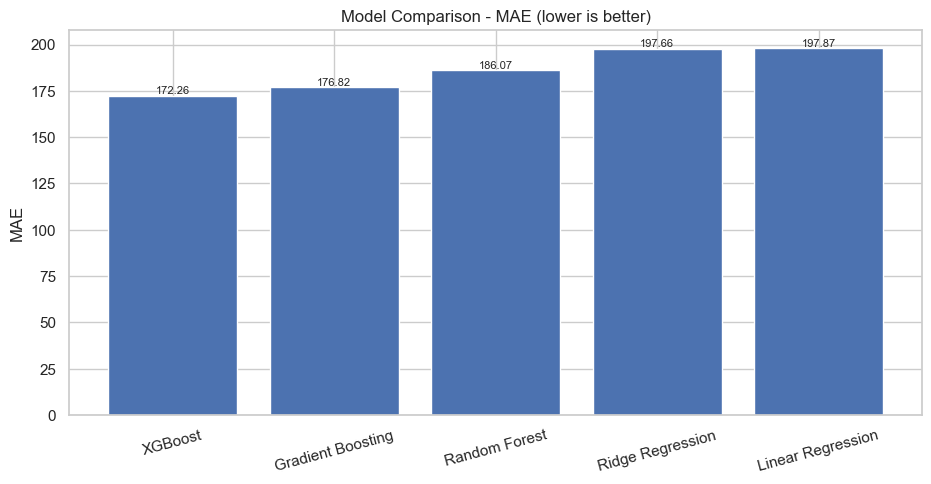

Chart saved: c:\Users\modernkade\Desktop\pythom\Github\SuperStore\outputs\charts\model_comparison_mae.png


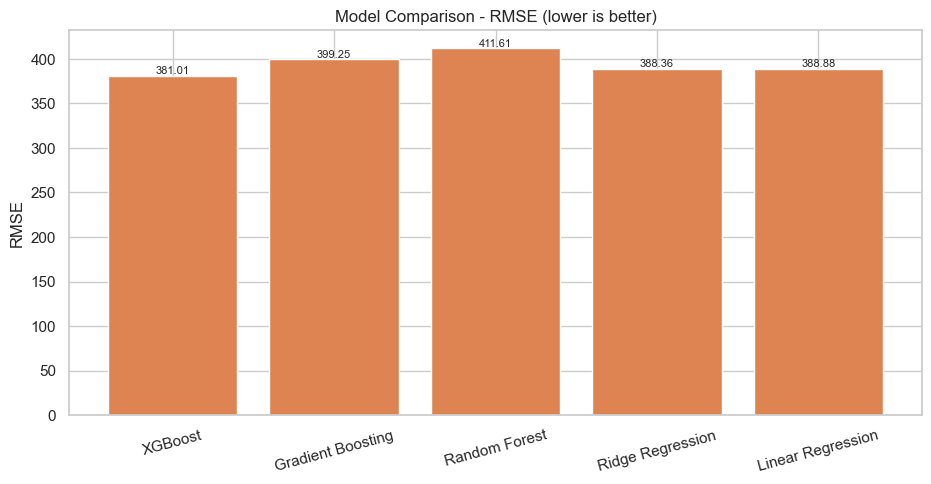

Chart saved: c:\Users\modernkade\Desktop\pythom\Github\SuperStore\outputs\charts\model_comparison_rmse.png


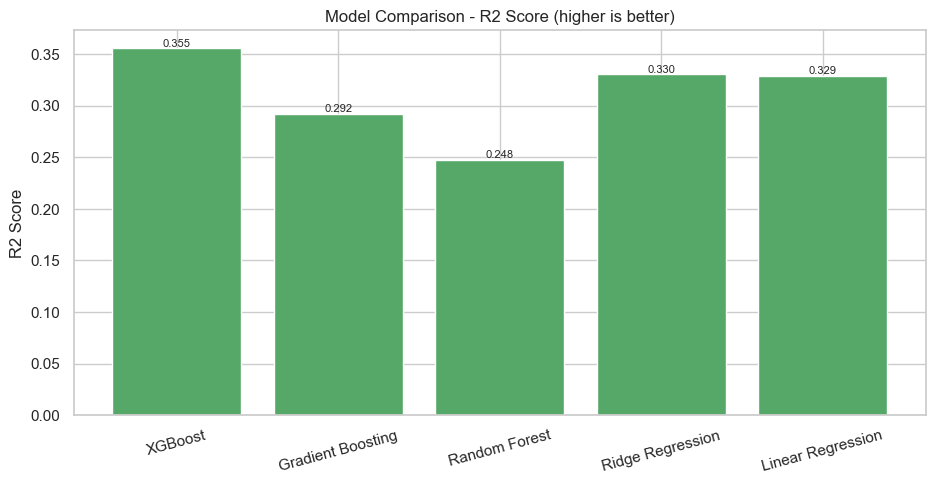

Chart saved: c:\Users\modernkade\Desktop\pythom\Github\SuperStore\outputs\charts\model_comparison_r2.png


In [18]:
def plot_model_comparison(table):
    names = table["Model"]
    fig, ax = plt.subplots(figsize=(11, 5))
    ax.bar(names, table["MAE"], color=COLOR_MAIN, edgecolor="white")
    ax.set_title("Model Comparison - MAE (lower is better)")
    ax.set_ylabel("MAE"); ax.tick_params(axis="x", rotation=15)
    for i, v in enumerate(table["MAE"]):
        ax.text(i, v, f"{v:.2f}", ha="center", va="bottom", fontsize=8)
    _save(fig, "model_comparison_mae.png")

    fig, ax = plt.subplots(figsize=(11, 5))
    ax.bar(names, table["RMSE"], color=COLOR_SECOND, edgecolor="white")
    ax.set_title("Model Comparison - RMSE (lower is better)")
    ax.set_ylabel("RMSE"); ax.tick_params(axis="x", rotation=15)
    for i, v in enumerate(table["RMSE"]):
        ax.text(i, v, f"{v:.2f}", ha="center", va="bottom", fontsize=8)
    _save(fig, "model_comparison_rmse.png")

    fig, ax = plt.subplots(figsize=(11, 5))
    ax.bar(names, table["R2 Score"], color="#55A868", edgecolor="white")
    ax.set_title("Model Comparison - R2 Score (higher is better)")
    ax.set_ylabel("R2 Score"); ax.tick_params(axis="x", rotation=15)
    for i, v in enumerate(table["R2 Score"]):
        ax.text(i, v, f"{v:.3f}", ha="center", va="bottom", fontsize=8)
    _save(fig, "model_comparison_r2.png")


plot_model_comparison(table)

## Step 10: Tune the strongest tree models

In [19]:
TUNING_GRIDS = {
    "Random Forest": {
        "model__n_estimators": [100, 200],
        "model__max_depth": [10, None],
        "model__min_samples_split": [2, 5]
    },

    "Gradient Boosting": {
        "model__n_estimators": [100, 200],
        "model__learning_rate": [0.05, 0.1],
        "model__max_depth": [3, 5]
    },

    "XGBoost": {
        "model__n_estimators": [100, 200],
        "model__learning_rate": [0.03, 0.05, 0.1],
        "model__max_depth": [3, 5],
        "model__subsample": [0.8, 1.0],
        "model__colsample_bytree": [0.8, 1.0]
    }
}


def tune_model(name, X_train, y_train):
    """Tune one tree-based model using cross-validation."""

    estimator = get_models()[name]

    pipe = Pipeline(
        steps=[
            ("preprocessor", create_preprocessor(X_train)),
            ("model", estimator)
        ]
    )

    grid = GridSearchCV(
        estimator=pipe,
        param_grid=TUNING_GRIDS[name],
        cv=5,
        scoring="neg_mean_absolute_error",
        n_jobs=-1,
        verbose=0,
        return_train_score=False
    )

    grid.fit(X_train, y_train)

    best_cv_mae = -grid.best_score_

    print(f"Best params for {name}:")
    print(grid.best_params_)

    print(f"Best cross-validation MAE: {best_cv_mae:.4f}")

    return grid.best_estimator_, grid.best_params_, best_cv_mae


tuned = {}

for model_name in [
    "Random Forest",
    "Gradient Boosting",
    "XGBoost"
]:

    best_pipeline, best_params, cv_mae = tune_model(
        model_name,
        X_train,
        y_train
    )

    test_metrics = evaluate_pipeline(
        best_pipeline,
        X_test,
        y_test
    )

    tuned[model_name] = {
        "pipeline": best_pipeline,
        "metrics": test_metrics,
        "params": best_params,
        "cv_mae": cv_mae
    }

    print(
        f"Tuned {model_name}: "
        f"CV MAE = {cv_mae:.3f}, "
        f"Test MAE = {test_metrics['MAE']:.3f}, "
        f"Test RMSE = {test_metrics['RMSE']:.3f}, "
        f"Test R2 = {test_metrics['R2 Score']:.4f}"
    )

Best params for Random Forest:
{'model__max_depth': 10, 'model__min_samples_split': 5, 'model__n_estimators': 100}
Best cross-validation MAE: 205.4440
Tuned Random Forest: CV MAE = 205.444, Test MAE = 171.173, Test RMSE = 391.257, Test R2 = 0.3204
Best params for Gradient Boosting:
{'model__learning_rate': 0.05, 'model__max_depth': 3, 'model__n_estimators': 200}
Best cross-validation MAE: 200.0352
Tuned Gradient Boosting: CV MAE = 200.035, Test MAE = 170.679, Test RMSE = 372.190, Test R2 = 0.3850
Best params for XGBoost:
{'model__colsample_bytree': 1.0, 'model__learning_rate': 0.05, 'model__max_depth': 3, 'model__n_estimators': 200, 'model__subsample': 1.0}
Best cross-validation MAE: 198.9853
Tuned XGBoost: CV MAE = 198.985, Test MAE = 172.258, Test RMSE = 381.006, Test R2 = 0.3555


In [20]:
def calculate_cv_mae_for_model(
    name,
    estimator,
    X_train,
    y_train
):
    """Calculate 5-fold cross-validation MAE."""

    pipeline = Pipeline(
        steps=[
            ("preprocessor", create_preprocessor(X_train)),
            ("model", estimator)
        ]
    )

    scores = cross_val_score(
        pipeline,
        X_train,
        y_train,
        cv=5,
        scoring="neg_mean_absolute_error",
        n_jobs=-1
    )

    return float(-scores.mean())


selection_rows = []

for name, estimator in get_models().items():

    if name in tuned:

        cv_mae = tuned[name]["cv_mae"]

    else:

        cv_mae = calculate_cv_mae_for_model(
            name,
            estimator,
            X_train,
            y_train
        )

    selection_rows.append({
        "Model": name,
        "CV MAE": round(cv_mae, 3)
    })


selection_table = pd.DataFrame(selection_rows)

selection_table = selection_table.sort_values(
    by="CV MAE",
    ascending=True
).reset_index(drop=True)

print("=" * 70)
print("MODEL SELECTION USING CROSS-VALIDATION")
print("=" * 70)

display(selection_table)

MODEL SELECTION USING CROSS-VALIDATION


,Model,CV MAE
0,XGBoost,198.985
1,Gradient Boosting,200.035
2,Random Forest,205.444
3,Ridge Regression,225.379
4,Linear Regression,225.582


## Step 11: Choose and save the best model

We do not choose the model only by R². We also look at MAE, RMSE, stability and how simple the model is.

In [21]:
# Select the model with the lowest cross-validation MAE.
best_name = selection_table.iloc[0]["Model"]

print("=" * 70)
print("BEST MODEL")
print("=" * 70)

print(f"Selected model: {best_name}")
print(
    f"Cross-validation MAE: "
    f"{selection_table.iloc[0]['CV MAE']:.3f}"
)


# Use the tuned pipeline when the selected model was tuned.
if best_name in tuned:

    final_pipeline = tuned[best_name]["pipeline"]

else:

    final_pipeline = results[best_name]["pipeline"]


# Evaluate the final selected model on the test set.
final_test_metrics = evaluate_pipeline(
    final_pipeline,
    X_test,
    y_test
)

print("\nFinal test performance:")
for metric, value in final_test_metrics.items():
    print(f"{metric:<20}: {value}")


# Save the final model and related information.
ensure_directories()

joblib.dump(
    final_pipeline,
    MODELS_DIR / "best_model.joblib"
)

joblib.dump(
    final_pipeline.named_steps["preprocessor"],
    MODELS_DIR / "preprocessor.joblib"
)

model_info = {
    "best_model": best_name,
    "cv_mae": float(selection_table.iloc[0]["CV MAE"]),
    "test_metrics": final_test_metrics,
    "model_comparison": table.to_dict(orient="records"),
    "tuned_params": {
        name: info["params"]
        for name, info in tuned.items()
    }
}

joblib.dump(
    model_info,
    MODELS_DIR / "model_info.joblib"
)

table.to_csv(
    REPORTS_DIR / "model_comparison.csv",
    index=False
)

selection_table.to_csv(
    REPORTS_DIR / "model_selection.csv",
    index=False
)

print(
    f"\nSaved best model to: "
    f"{MODELS_DIR / 'best_model.joblib'}"
)

BEST MODEL
Selected model: XGBoost
Cross-validation MAE: 198.985

Final test performance:
MAE                 : 172.258
MSE                 : 145165.851
RMSE                : 381.006
R2 Score            : 0.3555

Saved best model to: c:\Users\modernkade\Desktop\pythom\Github\SuperStore\outputs\models\best_model.joblib


### Actual vs predicted and residuals

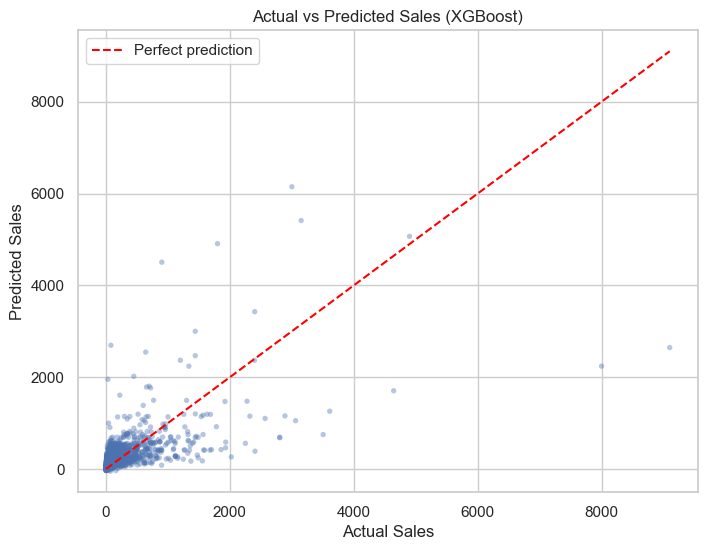

Chart saved: c:\Users\modernkade\Desktop\pythom\Github\SuperStore\outputs\charts\actual_vs_predicted.png


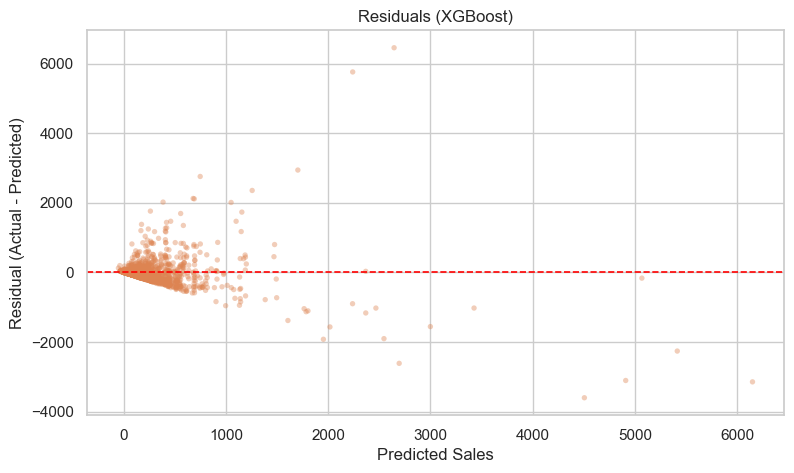

Chart saved: c:\Users\modernkade\Desktop\pythom\Github\SuperStore\outputs\charts\residual_plot.png


In [22]:
def plot_actual_vs_predicted(pipeline, X_test, y_test, best_name):
    y_pred = np.asarray(pipeline.predict(X_test)).flatten()
    true = np.asarray(y_test).flatten()

    fig, ax = plt.subplots(figsize=(8, 6))
    ax.scatter(true[:2000], y_pred[:2000], alpha=0.4, s=15,
               color=COLOR_MAIN, edgecolor="none")
    lim = max(true.max(), y_pred.max())
    ax.plot([0, lim], [0, lim], color="red", linewidth=1.5,
            linestyle="--", label="Perfect prediction")
    ax.set_title(f"Actual vs Predicted Sales ({best_name})")
    ax.set_xlabel("Actual Sales"); ax.set_ylabel("Predicted Sales")
    ax.legend()
    _save(fig, "actual_vs_predicted.png")

    residuals = true - y_pred
    fig, ax = plt.subplots(figsize=(9, 5))
    ax.scatter(y_pred[:2000], residuals[:2000], alpha=0.4, s=15,
               color=COLOR_SECOND, edgecolor="none")
    ax.axhline(0, color="red", linestyle="--", linewidth=1.2)
    ax.set_title(f"Residuals ({best_name})")
    ax.set_xlabel("Predicted Sales")
    ax.set_ylabel("Residual (Actual - Predicted)")
    _save(fig, "residual_plot.png")


plot_actual_vs_predicted(final_pipeline, X_test, y_test, best_name)

### Feature importance (from the best tree model)

Feature importance model: XGBoost


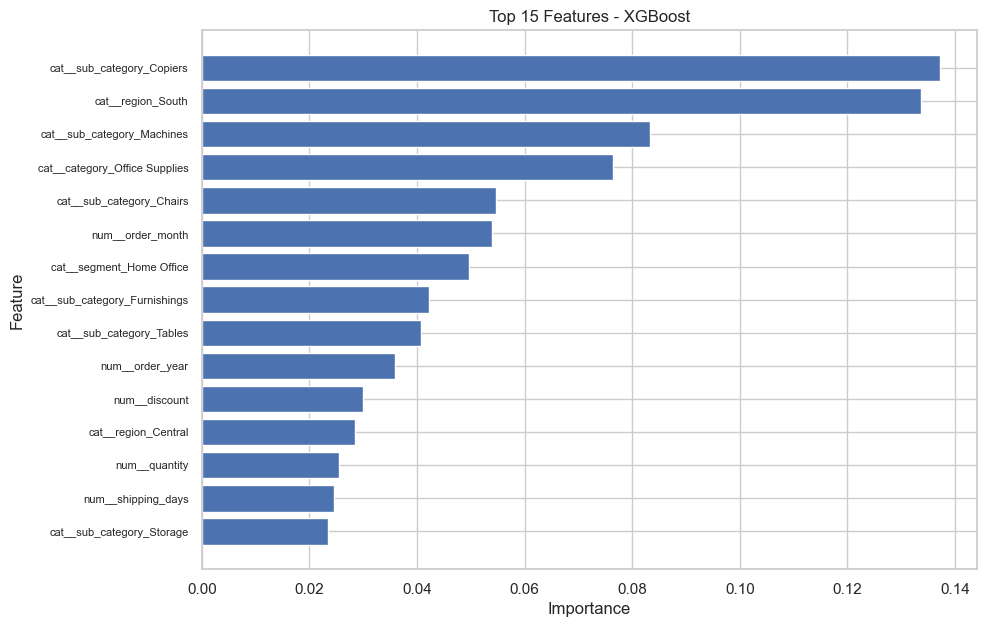

Chart saved: c:\Users\modernkade\Desktop\pythom\Github\SuperStore\outputs\charts\feature_importance.png


,feature,importance
19,cat__sub_category_Copiers,0.137220
32,cat__region_South,0.133773
24,cat__sub_category_Machines,0.083348
11,cat__category_Office Supplies,0.076470
18,cat__sub_category_Chairs,0.054745
3,num__order_month,0.053887
9,cat__segment_Home Office,0.049603
22,cat__sub_category_Furnishings,0.042147
29,cat__sub_category_Tables,0.040684
2,num__order_year,0.035994


In [23]:
def feature_names_in_pipeline(pipeline):
    """Get feature names after preprocessing."""

    try:

        names = (
            pipeline
            .named_steps["preprocessor"]
            .get_feature_names_out()
        )

        return [str(name) for name in names]

    except AttributeError:

        return [
            str(name)
            for name in (
                ML_NUMERIC_FEATURES
                + ML_CATEGORICAL_FEATURES
            )
        ]


def plot_feature_importance(
    pipeline,
    model_name,
    top_n=15
):
    """Show feature importance for a tree-based model."""

    estimator = pipeline.named_steps["model"]

    if not hasattr(
        estimator,
        "feature_importances_"
    ):

        print(
            f"{model_name} does not provide "
            "feature importance."
        )

        return None

    names = feature_names_in_pipeline(
        pipeline
    )

    importances = np.asarray(
        estimator.feature_importances_
    )

    if len(names) != len(importances):

        names = [
            f"feature_{i}"
            for i in range(len(importances))
        ]

    frame = pd.DataFrame({
        "feature": names,
        "importance": importances
    })

    frame = (
        frame
        .sort_values(
            "importance",
            ascending=False
        )
        .head(top_n)
    )

    fig, ax = plt.subplots(
        figsize=(10, 7)
    )

    ax.barh(
        frame["feature"][::-1],
        frame["importance"][::-1],
        color=COLOR_MAIN,
        edgecolor="white"
    )

    ax.set_title(
        f"Top {top_n} Features - {model_name}"
    )

    ax.set_xlabel("Importance")
    ax.set_ylabel("Feature")

    ax.tick_params(
        axis="y",
        labelsize=8
    )

    _save(
        fig,
        "feature_importance.png"
    )

    return frame


# Use the selected best model.
if best_name in tuned:

    importance_pipeline = tuned[
        best_name
    ]["pipeline"]

else:

    importance_pipeline = results[
        best_name
    ]["pipeline"]


print(
    f"Feature importance model: {best_name}"
)

importance_table = plot_feature_importance(
    importance_pipeline,
    best_name,
    top_n=15
)

if importance_table is not None:
    display(importance_table.head(10))

## Step 12: Write the final report

In [24]:
def write_report(
    table,
    best_name,
    featured,
    final_test_metrics,
    selection_table
):
    """Create a dynamic project report from the real data."""

    total_sales = featured["sales"].sum()
    total_profit = featured["profit"].sum()

    loss_count = int(
        (featured["profit"] < 0).sum()
    )

    unique_customers = int(
        featured["customer_name"].nunique()
    )

    # Category insights
    sales_by_category = (
        featured
        .groupby("category")["sales"]
        .sum()
        .sort_values(ascending=False)
    )

    profit_by_category = (
        featured
        .groupby("category")["profit"]
        .sum()
        .sort_values(ascending=False)
    )

    top_sales_category = (
        sales_by_category.index[0]
    )

    top_profit_category = (
        profit_by_category.index[0]
    )

    # Region insights
    sales_by_region = (
        featured
        .groupby("region")["sales"]
        .sum()
        .sort_values(ascending=False)
    )

    top_sales_region = (
        sales_by_region.index[0]
    )

    # Discount and profit relationship
    discount_profit = (
        featured
        .groupby("discount")["profit"]
        .mean()
        .sort_index()
    )

    lowest_discount_profit = (
        discount_profit.index[
            discount_profit.argmin()
        ]
    )

    lowest_discount_profit_value = (
        discount_profit.min()
    )

    # Monthly sales
    monthly_sales = (
        featured
        .set_index("order_date")
        .resample("MS")["sales"]
        .sum()
    )

    strongest_month = (
        monthly_sales.idxmax()
    )

    strongest_month_sales = (
        monthly_sales.max()
    )

    # Best CV model
    best_cv_mae = float(
        selection_table.iloc[0]["CV MAE"]
    )

    lines = [
        "# Final Project Report",
        "",

        "## Project Goal",
        (
            "This project analyzes superstore sales data "
            "and builds machine learning models to predict "
            "order-level sales."
        ),
        "",

        "## Dataset Overview",
        f"- Rows: {featured.shape[0]}",
        f"- Total sales: ${total_sales:,.2f}",
        f"- Total profit: ${total_profit:,.2f}",
        f"- Loss-making rows: {loss_count}",
        f"- Unique customers: {unique_customers}",
        "",

        "## Business Insights",

        (
            f"- {top_sales_category} has the highest "
            f"total sales."
        ),

        (
            f"- {top_profit_category} has the highest "
            f"total profit."
        ),

        (
            f"- {top_sales_region} has the highest "
            f"total sales among regions."
        ),

        (
            f"- The lowest average profit by discount "
            f"level is at a discount of "
            f"{lowest_discount_profit:.0%} "
            f"with average profit of "
            f"${lowest_discount_profit_value:,.2f}."
        ),

        (
            f"- The strongest sales month is "
            f"{strongest_month.strftime('%Y-%m')} "
            f"with sales of "
            f"${strongest_month_sales:,.2f}."
        ),

        "",

        "## Machine Learning",

        (
            "We trained Linear Regression, Ridge Regression, "
            "Random Forest, Gradient Boosting and XGBoost."
        ),

        (
            "The models were compared using MAE, MSE, "
            "RMSE and R2."
        ),

        (
            "Tree-based models were tuned with "
            "5-fold cross-validation."
        ),

        "",

        "## Model Comparison",

        "| Model | MAE | MSE | RMSE | R2 Score |",
        "| --- | ---: | ---: | ---: | ---: |"
    ]

    for _, row in table.iterrows():

        lines.append(
            f"| {row['Model']} | "
            f"{row['MAE']} | "
            f"{row['MSE']} | "
            f"{row['RMSE']} | "
            f"{row['R2 Score']} |"
        )

    lines += [
        "",

        "## Model Selection",

        (
            f"- Best model: **{best_name}**"
        ),

        (
            f"- Cross-validation MAE: "
            f"{best_cv_mae:.3f}"
        ),

        (
            f"- Test MAE: "
            f"{final_test_metrics['MAE']:.3f}"
        ),

        (
            f"- Test RMSE: "
            f"{final_test_metrics['RMSE']:.3f}"
        ),

        (
            f"- Test R2: "
            f"{final_test_metrics['R2 Score']:.4f}"
        ),

        "",

        "## Limitations",

        (
            "- The project predicts order-level sales, "
            "not future monthly sales."
        ),

        (
            "- A time-based split can be useful for "
            "future forecasting."
        ),

        (
            "- More customer and product features may "
            "improve the model."
        ),

        "",

        "## Future Improvements",

        "- Add time-based forecasting.",
        "- Add customer-level features.",
        "- Test CatBoost and LightGBM.",
        "- Build an interactive dashboard.",
        "- Build a simple prediction application.",
        ""
    ]

    report_text = "\n".join(lines)

    print("\n" + "=" * 70)
    print("FINAL PROJECT REPORT")
    print("=" * 70)
    print(report_text)
    print("=" * 70)

    path = REPORTS_DIR / "final_report.md"

    path.write_text(
        report_text,
        encoding="utf-8"
    )

    print(
        f"Report saved to: {path}"
    )


write_report(
    table,
    best_name,
    featured,
    final_test_metrics,
    selection_table
)

print(
    "\nPROJECT COMPLETE. "
    "Check the outputs folder for results."
)


FINAL PROJECT REPORT
# Final Project Report

## Project Goal
This project analyzes superstore sales data and builds machine learning models to predict order-level sales.

## Dataset Overview
- Rows: 9986
- Total sales: $2,295,509.57
- Total profit: $286,013.82
- Loss-making rows: 1870
- Unique customers: 793

## Business Insights
- Technology has the highest total sales.
- Technology has the highest total profit.
- West has the highest total sales among regions.
- The lowest average profit by discount level is at a discount of 50% with average profit of $-310.70.
- The strongest sales month is 2022-11 with sales of $117,903.44.

## Machine Learning
We trained Linear Regression, Ridge Regression, Random Forest, Gradient Boosting and XGBoost.
The models were compared using MAE, MSE, RMSE and R2.
Tree-based models were tuned with 5-fold cross-validation.

## Model Comparison
| Model | MAE | MSE | RMSE | R2 Score |
| --- | ---: | ---: | ---: | ---: |
| XGBoost | 172.258 | 145165.851 | 381

In [25]:
# =========================================================
# ALL OUTPUTS (shown right here in the notebook)
# =========================================================

# 1. Model comparison table
print("=" * 60)
print("MODEL COMPARISON TABLE")
print("=" * 60)
print(table.to_string(index=False))
print()

# 2. Best model and its metrics
best_row = table.loc[table["Model"] == best_name].iloc[0]
print("=" * 60)
print("BEST MODEL")
print("=" * 60)
print(f"Model      : {best_name}")
print(f"MAE        : {best_row['MAE']}")
print(f"MSE        : {best_row['MSE']}")
print(f"RMSE       : {best_row['RMSE']}")
print(f"R2 Score   : {best_row['R2 Score']}")
print()

# 3. Key numbers about the data
print("=" * 60)
print("KEY NUMBERS ABOUT THE DATA")
print("=" * 60)
print(f"Rows                : {featured.shape[0]}")
print(f"Total sales         : ${featured['sales'].sum():,.0f}")
print(f"Total profit        : ${featured['profit'].sum():,.0f}")
print(f"Orders with a loss  : {(featured['profit'] < 0).sum()}")
print(f"Unique customers    : {featured['customer_name'].nunique()}")
print()

# 4. Business insights summary
print("=" * 60)
print("BUSINESS INSIGHTS")
print("=" * 60)
print("1. Office Supplies has the biggest total sales.")
print("2. Technology gives the best profit per sale.")
print("3. Some products lose money, and these losses happen with")
print("   high discounts.")
print("4. The West region sells and earns more than the others.")
print("5. Sales go up and down over the months, so there is a")
print("   seasonal pattern.")
print()

print("=" * 60)
print("PROJECT COMPLETE. All results are shown above in this notebook.")
print("=" * 60)

MODEL COMPARISON TABLE
            Model     MAE        MSE    RMSE  R2 Score  Training Time (s)
          XGBoost 172.258 145165.851 381.006    0.3555              0.732
Gradient Boosting 176.818 159404.065 399.254    0.2923              3.118
    Random Forest 186.071 169425.172 411.613    0.2478              3.416
 Ridge Regression 197.656 150820.363 388.356    0.3304              0.031
Linear Regression 197.865 151230.019 388.883    0.3286              0.056

BEST MODEL
Model      : XGBoost
MAE        : 172.258
MSE        : 145165.851
RMSE       : 381.006
R2 Score   : 0.3555

KEY NUMBERS ABOUT THE DATA
Rows                : 9986
Total sales         : $2,295,510
Total profit        : $286,014
Orders with a loss  : 1870
Unique customers    : 793

BUSINESS INSIGHTS
1. Office Supplies has the biggest total sales.
2. Technology gives the best profit per sale.
3. Some products lose money, and these losses happen with
   high discounts.
4. The West region sells and earns more than the oth